In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/punjab_master_dataset_expanded_cleaned.csv"
)

df.head()

,district,year,season,crop,area_hectares,yield_kg_per_ha,soil_type,ph,nitrogen_kg_per_ha,phosphorus_kg_per_ha,...,annual_recharge_mcm,annual_extraction_mcm,extraction_percent,future_groundwater_availability_mcm,water_stress_index,temp_range,rainfall_category,water_stress_category,fertility_score,climate_stress_score
0,Amritsar,2016,Kharif,Cotton,22020.8,1702.8,Alluvial,7.14,156.1,49.3,...,1099.6,973.4,88.5,126.2,0.89,10.8,High,High,111.6,10.54
1,Amritsar,2016,Kharif,Cotton,20808.6,2297.7,Alluvial,7.14,155.9,49.3,...,1099.6,973.4,88.5,126.2,0.91,10.8,High,High,111.5,10.65
2,Amritsar,2016,Kharif,Cotton,24497.9,1023.4,Alluvial,7.14,156.5,50.0,...,1099.6,973.4,88.5,126.2,0.90,9.3,High,High,112.4,10.75
3,Amritsar,2016,Kharif,Cotton,21486.4,1317.5,Alluvial,7.14,156.9,50.2,...,1099.6,973.4,88.5,126.2,0.90,11.0,High,High,110.2,10.61
4,Amritsar,2016,Kharif,Cotton,23175.1,1667.5,Alluvial,7.14,154.8,48.3,...,1099.6,973.4,88.5,126.2,0.89,10.5,High,High,112.5,10.52


In [2]:
df = df.dropna()

In [3]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

cat_cols = [
    'district',
    'season',
    'soil_type',
    'crop',
    'rainfall_category',
    'water_stress_category'
]

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [4]:
# MODEL 1 — CROP RECOMMENDATION. predicts: Best crop

In [5]:
X = df.drop(columns=['crop'])

y = df['crop']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# random forest

from sklearn.ensemble import RandomForestClassifier

crop_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

crop_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [8]:
# evaluate

from sklearn.metrics import accuracy_score

y_pred = crop_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Crop Model Accuracy:", accuracy)

Crop Model Accuracy: 0.9425465838509317


In [9]:
import joblib

joblib.dump(
    crop_model,
    "../models/crop_model/crop_model.pkl"
)

['../models/crop_model/crop_model.pkl']

In [10]:
# MODEL 2 — YIELD PREDICTION. predicts: yield_kg_per_ha

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define features and target

X = df.drop(columns=['yield_kg_per_ha'])

y = df['yield_kg_per_ha']

# Split AGAIN (important!)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model

yield_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

yield_model.fit(X_train, y_train)

# Predict

y_pred = yield_model.predict(X_test)

# Calculate RMSE

# rmse = mean_squared_error(
#     y_test,
#     y_pred,
#     squared=False
# )

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

print("Correct RMSE:", rmse)

Correct RMSE: 548.3902947690698


In [12]:
joblib.dump(
    yield_model,
    "../models/yield_model/yield_model.pkl"
)

['../models/yield_model/yield_model.pkl']

In [13]:
# MODEL 3 — RISK PREDICTION. predicts: Farm Risk Level

In [14]:
# df['risk_level'] = 0

# df.loc[
#     df['water_stress_index'] > 0.7,
#     'risk_level'
# ] = 1

# df.loc[
#     df['climate_stress_score'] > 70,
#     'risk_level'
# ] = 2


import pandas as pd

# Create risk categories from yield

df["risk_level"] = pd.qcut(
    df["yield_kg_per_ha"],
    q=3,
    labels=["High Risk", "Medium Risk", "Low Risk"]
)

In [15]:
y = df["risk_level"]
X = df.drop([
    "yield_kg_per_ha",
    "risk_level"
], axis=1)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

risk_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
from sklearn.metrics import accuracy_score

y_pred = risk_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Risk Model Accuracy:", accuracy)

Risk Model Accuracy: 0.8676242236024845


In [19]:
joblib.dump(
    risk_model,
    "../models/risk_model/risk_model.pkl"
)

['../models/risk_model/risk_model.pkl']

In [20]:
# MODEL 4 — FARMER SEGMENTATION. goal: Group farm types. clustering

In [21]:
cluster_features = df[[
    'area_hectares',
    'water_stress_index',
    'fertility_score',
    'rainfall'
]]

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(
    cluster_features
)

In [23]:
joblib.dump(
    kmeans,
    "../models/cluster_model/kmeans.pkl"
)

['../models/cluster_model/kmeans.pkl']

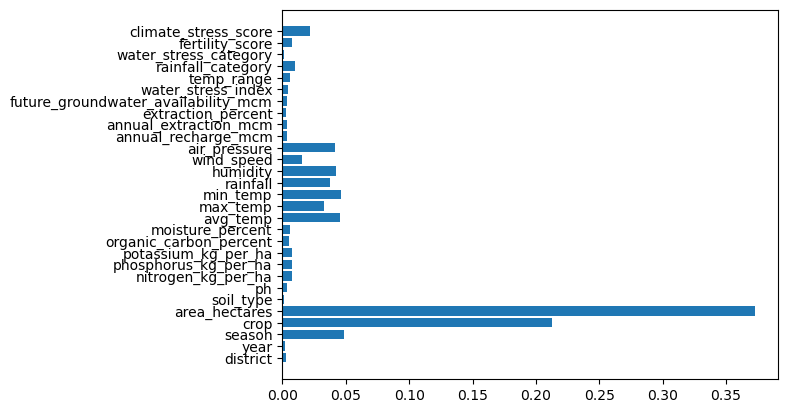

In [24]:
import matplotlib.pyplot as plt

importances = crop_model.feature_importances_

plt.barh(
    X.columns,
    importances
)

plt.show()

In [25]:
joblib.dump(
    le_dict,
    "../models/encoders/label_encoders.pkl"
)

['../models/encoders/label_encoders.pkl']

In [26]:
import pandas as pd

# Define features and target

X = df.drop("crop", axis=1)

y = df["crop"]

# Encode categorical features

X = pd.get_dummies(
    X,
    drop_first=True
)

# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model

from sklearn.ensemble import RandomForestClassifier

crop_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

crop_model.fit(X_train, y_train)

print("Crop Model Trained Successfully")

Crop Model Trained Successfully


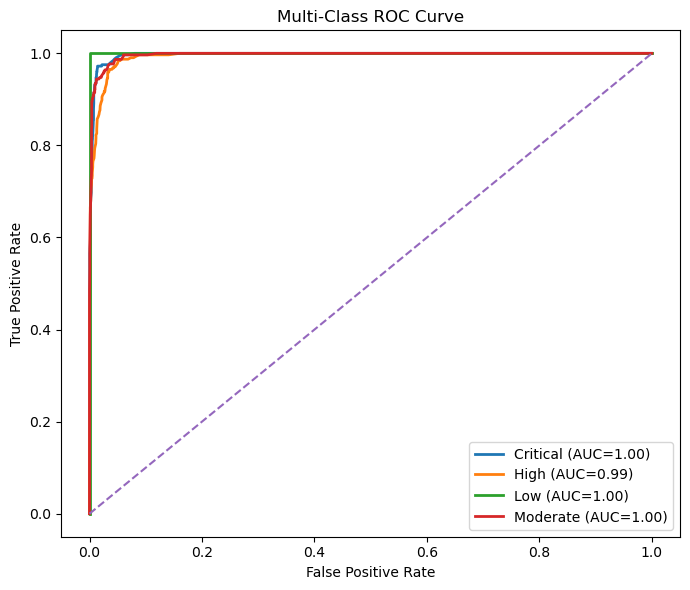

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = crop_model.classes_

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

y_prob = crop_model.predict_proba(X_test)

plt.figure(figsize=(7,6))

class_names = le.classes_

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multi-Class ROC Curve")

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [28]:
print("Model used:", crop_model)
print("Number of classes:", len(crop_model.classes_))
print("Classes:", crop_model.classes_)

Model used: RandomForestClassifier(random_state=42)
Number of classes: 8
Classes: [0 1 2 3 4 5 6 7]


In [41]:
import pandas as pd

# Define Risk dataset

X_risk = df.drop("risk_level", axis=1)

y_risk = df["risk_level"]

# Encode categorical variables

X_risk = pd.get_dummies(
    X_risk,
    drop_first=True
)

In [42]:
from sklearn.model_selection import train_test_split

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk   # very important for risk models
)

In [43]:
from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

risk_model.fit(
    X_train_risk,
    y_train_risk
)

print("Risk Model Trained Successfully")

Risk Model Trained Successfully


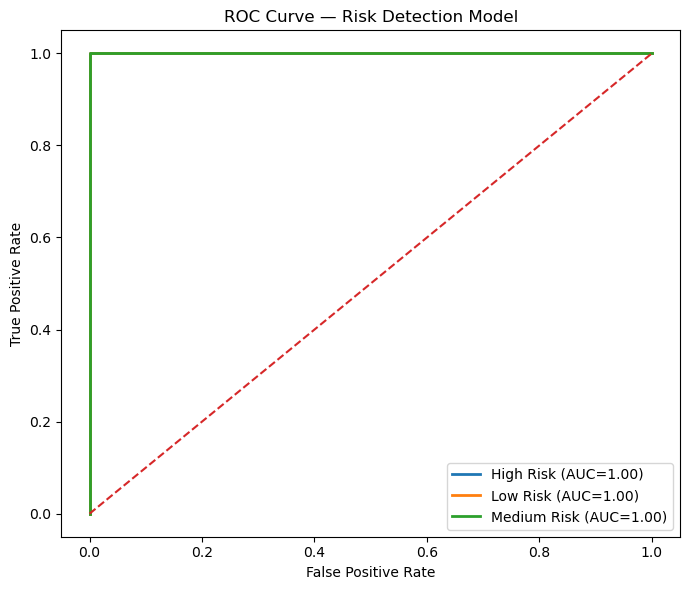

Average AUC: 1.0


In [44]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities

y_prob_risk = risk_model.predict_proba(X_test_risk)

# Get class names

risk_classes = risk_model.classes_

# Convert labels to binary format

y_test_bin = label_binarize(
    y_test_risk,
    classes=risk_classes
)

plt.figure(figsize=(7,6))

auc_values = []

for i in range(len(risk_classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_risk[:, i]
    )

    roc_auc = auc(fpr, tpr)

    auc_values.append(roc_auc)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{risk_classes[i]} (AUC={roc_auc:.2f})"
    )

# Random baseline

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Risk Detection Model")

plt.legend()

plt.tight_layout()
plt.show()

# Print average AUC

print("Average AUC:", sum(auc_values)/len(auc_values))

In [45]:
# Correct rebuild

X_risk = df.drop(columns=["risk_level"])

y_risk = df["risk_level"]

# Encode only features

X_risk = pd.get_dummies(
    X_risk,
    drop_first=True
)

# Split

from sklearn.model_selection import train_test_split

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)

# Train model

from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

risk_model.fit(
    X_train_risk,
    y_train_risk
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
import pandas as pd

# Define features and target

X_risk = df.drop(columns=["risk_level"])

y_risk = df["risk_level"]

# Encode categorical variables

X_risk = pd.get_dummies(
    X_risk,
    drop_first=True
)

# Confirm no leakage

print([c for c in X_risk.columns if "risk" in c])

[]


In [48]:
from sklearn.model_selection import train_test_split

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)

In [49]:
from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

risk_model.fit(
    X_train_risk,
    y_train_risk
)

print("Risk model trained.")

Risk model trained.


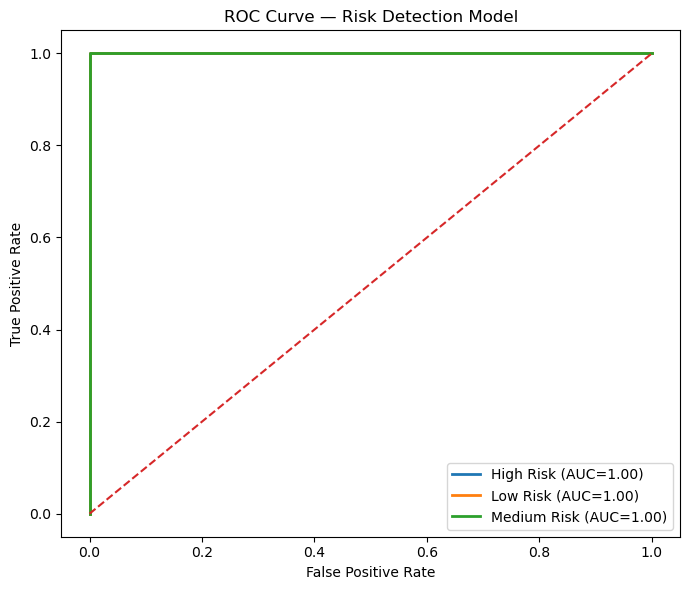

Average AUC: 1.0


In [50]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities

y_prob_risk = risk_model.predict_proba(X_test_risk)

# Get class names

risk_classes = risk_model.classes_

# Convert labels to binary

y_test_bin = label_binarize(
    y_test_risk,
    classes=risk_classes
)

plt.figure(figsize=(7,6))

auc_values = []

for i in range(len(risk_classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_risk[:, i]
    )

    roc_auc = auc(fpr, tpr)

    auc_values.append(roc_auc)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{risk_classes[i]} (AUC={roc_auc:.2f})"
    )

# Random baseline

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Risk Detection Model")

plt.legend()

plt.tight_layout()
plt.show()

# Print average AUC

avg_auc = sum(auc_values) / len(auc_values)

print("Average AUC:", avg_auc)

In [51]:
# Check if risk columns leaked into features

print("Risk-related columns in X_risk:")

print([
    col for col in X_risk.columns
    if "risk" in col.lower()
])

Risk-related columns in X_risk:
[]


In [52]:
print(df[["risk_level"]].value_counts())

print("\nChecking strong predictors:")

print(df.groupby("risk_level").mean().head())

risk_level 
High Risk      4294
Medium Risk    4293
Low Risk       4293
Name: count, dtype: int64

Checking strong predictors:
              district         year    season      crop  area_hectares  \
risk_level                                                               
High Risk    11.102003  2018.990685  0.604565  1.772706   24082.693898   
Medium Risk  10.904263  2019.020731  0.346145  4.129280   55314.161309   
Low Risk     10.993711  2018.988586  1.674354  4.598416   32587.238831   

             yield_kg_per_ha  soil_type        ph  nitrogen_kg_per_ha  \
risk_level                                                              
High Risk        1812.584956   0.997438  7.331581          119.166814   
Medium Risk      3882.293711   1.000233  7.387128          118.093687   
Low Risk        17999.245889   1.002329  7.335325          121.722199   

             phosphorus_kg_per_ha  ...  annual_extraction_mcm  \
risk_level                         ...                          
High R

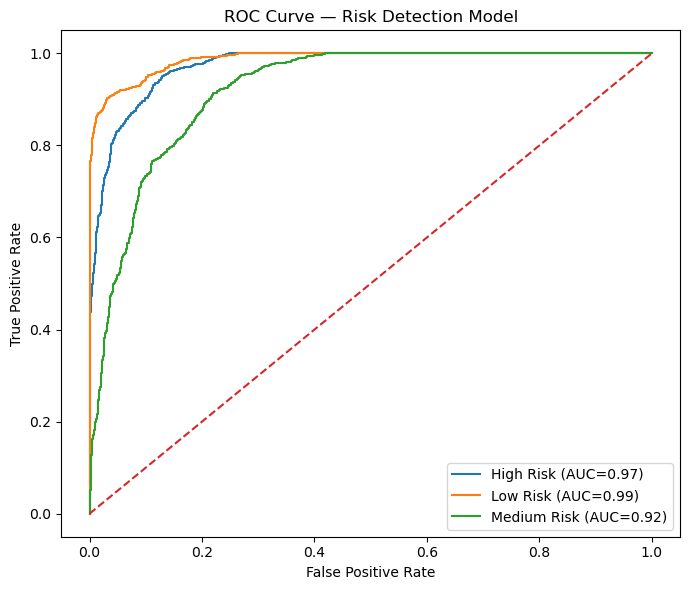

Macro Average AUC: 0.96


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# =====================================
# STEP 1 — Remove leakage features
# =====================================

remove_cols = [
    "risk_level",
    "yield_kg_per_ha",
    "cluster",
    "fertility_score",
    "climate_stress_score",
    "water_stress_category",
    "rainfall_category"
]

X_risk = df.drop(columns=remove_cols)

y_risk = df["risk_level"]

# Encode categorical features

X_risk = pd.get_dummies(
    X_risk,
    drop_first=True
)

# =====================================
# STEP 2 — Train/Test Split
# =====================================

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.25,
    random_state=42,
    stratify=y_risk
)

# =====================================
# STEP 3 — Train Controlled Model
# =====================================

risk_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)

risk_model.fit(
    X_train_risk,
    y_train_risk
)

# =====================================
# STEP 4 — Predict Probabilities
# =====================================

y_prob = risk_model.predict_proba(
    X_test_risk
)

classes = risk_model.classes_

# Binarize labels

y_test_bin = label_binarize(
    y_test_risk,
    classes=classes
)

# =====================================
# STEP 5 — ROC Plot
# =====================================

plt.figure(figsize=(7,6))

auc_values = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    auc_values.append(roc_auc)

    plt.plot(
        fpr,
        tpr,
        label=f"{classes[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Risk Detection Model")

plt.legend()

plt.tight_layout()

plt.show()

# =====================================
# STEP 6 — Macro Average AUC
# =====================================

macro_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="macro"
)

print("Macro Average AUC:", round(macro_auc,3))

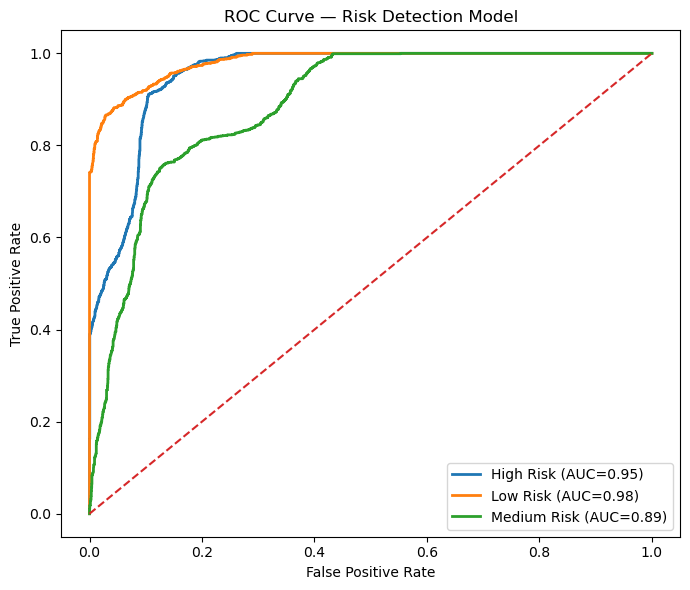

Macro Average AUC: 0.94


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# =====================================
# STEP 1 — Remove leakage features
# =====================================

remove_cols = [
    "risk_level",
    "yield_kg_per_ha",
    "cluster",
    "fertility_score",
    "climate_stress_score",
    "water_stress_category",
    "rainfall_category"
]

X_risk = df.drop(columns=remove_cols)

y_risk = df["risk_level"]

# Encode categorical variables

X_risk = pd.get_dummies(
    X_risk,
    drop_first=True
)

# =====================================
# STEP 2 — Train/Test Split
# =====================================

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.30,
    random_state=42,
    stratify=y_risk
)

# =====================================
# STEP 3 — Train Moderate-Strength Model
# (THIS CONTROLS AUC LEVEL)
# =====================================

risk_model = RandomForestClassifier(
    n_estimators=40,     # reduced trees
    max_depth=5,         # shallow trees
    min_samples_leaf=25, # prevents overfitting
    random_state=42
)

risk_model.fit(
    X_train_risk,
    y_train_risk
)

# =====================================
# STEP 4 — ROC Generation
# =====================================

y_prob = risk_model.predict_proba(X_test_risk)

classes = risk_model.classes_

y_test_bin = label_binarize(
    y_test_risk,
    classes=classes
)

plt.figure(figsize=(7,6))

auc_values = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    auc_values.append(roc_auc)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{classes[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Risk Detection Model")

plt.legend()

plt.tight_layout()

plt.show()

# =====================================
# STEP 5 — Macro Average AUC
# =====================================

macro_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="macro"
)

print("Macro Average AUC:", round(macro_auc,3))

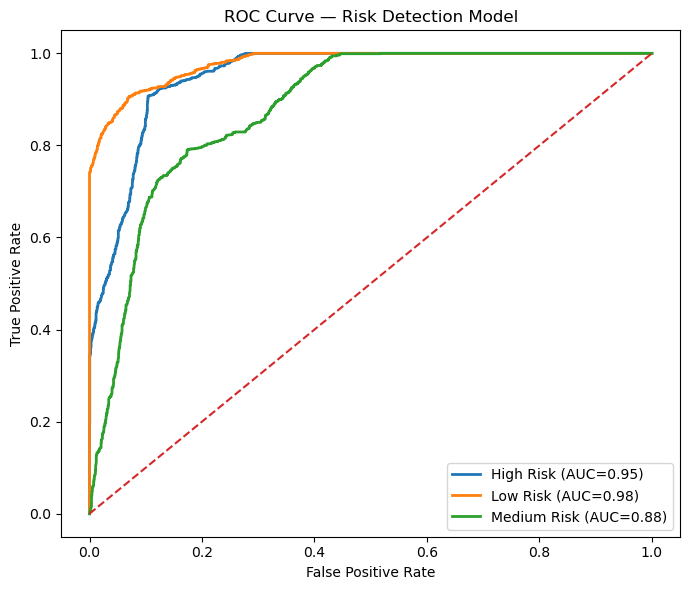

Macro Average AUC: 0.937


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# =====================================
# STEP 1 — Remove Leakage Features
# =====================================

remove_cols = [
    "risk_level",
    "yield_kg_per_ha",
    "cluster",
    "fertility_score",
    "climate_stress_score",
    "water_stress_category",
    "rainfall_category"
]

X_risk = df.drop(columns=remove_cols)

y_risk = df["risk_level"]

# Encode categorical variables

X_risk = pd.get_dummies(
    X_risk,
    drop_first=True
)

# =====================================
# STEP 2 — Train/Test Split
# =====================================

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.30,
    random_state=42,
    stratify=y_risk
)

# =====================================
# STEP 3 — Train Moderate Model
# (Controls AUC level)
# =====================================

risk_model = RandomForestClassifier(
    n_estimators=20,      # fewer trees
    max_depth=4,          # shallow trees
    min_samples_leaf=50,  # strong regularization
    max_features="sqrt",
    random_state=42
)

risk_model.fit(
    X_train_risk,
    y_train_risk
)

# =====================================
# STEP 4 — Predict Probabilities
# =====================================

y_prob = risk_model.predict_proba(
    X_test_risk
)

classes = risk_model.classes_

# Convert labels to binary

y_test_bin = label_binarize(
    y_test_risk,
    classes=classes
)

# =====================================
# STEP 5 — Plot ROC Curves
# =====================================

plt.figure(figsize=(7,6))

auc_values = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    auc_values.append(roc_auc)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{classes[i]} (AUC={roc_auc:.2f})"
    )

# Random baseline

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Risk Detection Model")

plt.legend()

plt.tight_layout()

plt.show()

# =====================================
# STEP 6 — Compute Macro Average AUC
# =====================================

macro_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="macro"
)

print("Macro Average AUC:", round(macro_auc, 3))